In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
import torch.nn as nn
import tiktoken
tokenizer = tiktoken.get_encoding('gpt2')
import torch
from torch.utils.data import Dataset,DataLoader

In [3]:
class DatasetV1(Dataset):
  def __init__(self,txt,tokenizer,max_len,stride):
    self.input_ids = []
    self.target_ids = []

    token_ids = tokenizer.encode(txt,allowed_special={'<|endoftext|>'})

    for i in range(0,len(token_ids)-max_len-1,stride):
      input_chunk = token_ids[i:i+max_len]
      target_chunk = token_ids[i+1:i+max_len+1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))


  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self,idx):
    return self.input_ids[idx],self.target_ids[idx]


def create_dataloader(txt,batch_size = 4,max_len = 256,stride=128,shuffle = True,
                      drop_last = True,num_workers = 0):
  tokenizer = tiktoken.get_encoding('gpt2')

  dataset = DatasetV1(txt,tokenizer,max_len,stride)

  dataloader = DataLoader(
      dataset=dataset,
      batch_size=batch_size,
      shuffle=shuffle,
      num_workers=num_workers
  )

  return dataloader

In [4]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

In [5]:
class MultiHeadAttentio(nn.Module):
  def __init__(self, d_in,d_out,num_heads,dropout,context_len,qvk_bias=False):
    super().__init__()
    assert (d_out % num_heads == 0), \
      "d_out must be divisible by num_heads"

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads

    self.W_query = nn.Linear(d_in,d_out,bias=qvk_bias)
    self.W_value = nn.Linear(d_in,d_out,bias=qvk_bias)
    self.W_key = nn.Linear(d_in,d_out,bias=qvk_bias)
    self.out_proj = nn.Linear(d_out,d_out) #linear layer to combine head outputs
    self.dropout = nn.Dropout(dropout)
    self.register_buffer(
        "mask", torch.triu(torch.ones(context_len,context_len),diagonal=1)
    )

  def forward(self,x):
    b,num_tokens,d_in = x.shape

    keys = self.W_key(x)
    values= self.W_value(x)
    queries = self.W_query(x)

    keys = keys.view(b,num_tokens,self.num_heads,self.head_dim)
    values = values.view(b,num_tokens,self.num_heads,self.head_dim)
    queries = queries.view(b,num_tokens,self.num_heads,self.head_dim)

    keys = keys.transpose(1,2)
    values = values.transpose(1,2)
    queries = queries.transpose(1,2)

    attn_scores = queries @ keys.transpose(-2,-1)

    mask_bool = self.mask.bool()[:num_tokens,:num_tokens]

    attn_scores = attn_scores.masked_fill(mask_bool,-torch.inf)

    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5,dim = -1)
    attn_weights = self.dropout(attn_weights)

    context_vec = (attn_weights @ values).transpose(1,2)

    context_vec = context_vec.contiguous().view(b,num_tokens,self.d_out)
    context_vec = self.out_proj(context_vec)

    return context_vec
    '''
    view(...) → you're collecting opinions from 4 experts (attention heads) and writing them all down on one page.

out_proj(...) → you're analyzing that combined report to make a decision, with learned weights.
'''


class LayerNorm(nn.Module):
  def __init__(self,emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self,x):
    mean = x.mean(dim = -1,keepdim = True)
    var = x.var(dim = -1,keepdim = True,unbiased = False)

    norm_x = (x-mean) / torch.sqrt(var + self.eps)

    return self.scale * norm_x + self.shift


class GELU(nn.Module):
  def __init__(self):
    super().__init__()
    self.register_buffer('c', torch.sqrt(torch.tensor(2.0 / torch.pi)))

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(self.c * (x + 0.044715 * x.pow(3))))




class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
        GELU(),
        nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"])
    )



  def forward(self,x):
    return self.layers(x)



#self, d_in,d_out,num_heads,dropout,context_len,qvk_bias=False
class TransformerBlock(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.att = MultiHeadAttentio(
        d_in = cfg["emb_dim"],
        d_out = cfg["emb_dim"],
        num_heads=cfg["n_heads"],
        dropout = cfg["drop_rate"],
        context_len = cfg["context_length"],
        qvk_bias = cfg["qvk_bias"]
    )
    self.ff = FeedForward(cfg)
    self.norm1 = LayerNorm(cfg["emb_dim"])
    self.norm2 = LayerNorm(cfg["emb_dim"])
    self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

  def forward(self, x):
    shortcut = x
    x = self.norm1(x)
    x = self.att(x) # shape [batchsize, num_token, emb_size]
    x = self.drop_shortcut(x)
    x = shortcut + x


    shortcut = x
    x = self.norm2(x)
    x = self.ff(x)
    x = self.drop_shortcut(x)
    x = x + shortcut

    return x


In [6]:
def generate_text_simple(model,idx,max_new_tokens,context_size,top_k = None,temperature = 0.0,eos_id = None):
  '''
  idx is (batch,tokens) array of indices in the current context'''


  for _ in range(max_new_tokens):
    '''
    crop current context if it exceeds the supported context size
    eg if LLM supports only 5 tokens, ant the context size is 10
    the only the last 5 tokens are used as context'''

    idx_cond = idx[:,-context_size:]

    with torch.no_grad():
      logits = model(idx_cond) # Batch , n_tokens, vocab_size

    logits = logits[:,-1,:]
    # Apply top-k filtering
    if top_k is not None:
        top_k = min(top_k, logits.size(-1))  # Handle edge case
        top_values, top_indices = torch.topk(logits, top_k, dim=-1)
        mask = torch.full_like(logits, float('-inf'))
        mask.scatter_(dim=-1, index=top_indices, src=top_values)
        logits = mask

    if temperature > 0:
      logits = logits / temperature
      prob = torch.softmax(logits,dim = -1)
      idx_next = torch.multinomial(prob,num_samples=1)

    else:
      idx_next = torch.argmax(logits,dim = -1,keepdim = True)

    if idx_next == eos_id:
      break

    idx = torch.cat((idx,idx_next),dim = -1)

  return idx


In [7]:
class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])
    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )
    self.final_norm = LayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

  def forward(self, in_idx):
    batch_size, seq_len = in_idx.shape
    token_embeds = self.tok_emb(in_idx)

    pos = torch.arange(seq_len, device=in_idx.device).unsqueeze(0)  # [1, seq_len]
    pos_embeds = self.pos_emb(pos)  # [1, seq_len, emb_dim]

# | Term        | What it Does              | Why It’s Important                          |
# | ----------- | ------------------------- | ------------------------------------------- |
# | `device`    | Controls CPU vs GPU       | Prevents device mismatch errors             |
# | `unsqueeze` | Adds a new axis to tensor | Helps with broadcasting and shape alignment |


    x = token_embeds + pos_embeds  # [batch_size, seq_len, emb_dim]
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)

    return logits


In [8]:
GPT_CONFIG_345M = {
    "vocab_size":50257,
    "context_length":1024,
    "emb_dim":1024,
    "n_heads":16,
    "n_layers":24,
    "drop_rate":0.0,
    "qvk_bias":True
}

gpt = GPTModel(GPT_CONFIG_345M)
gpt.eval();


In [9]:
checkpoint = torch.load('/content/drive/MyDrive/Colab Notebooks/gpt2(medium)pretrained_weights.pt')
gpt.load_state_dict(checkpoint)


<All keys matched successfully>

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttentio(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttentio(
        (W_query): Linear(in_

In [11]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpt = gpt.to(device)


token_ids = generate_text_simple(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_345M["context_length"],
    top_k=50,
    temperature=0.1
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


Output text:
 Every effort moves you forward. You're always moving forward. You're always moving forward."



In [12]:
import json

with open('/content/drive/MyDrive/Colab Notebooks/instruction-data.json','r') as file:
    data = json.load(file)

print(len(data))


1100


In [13]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describe a task. "
        f"Wriite a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = f"\n\n### Input:\n{entry['input']}" if entry['input'] else ""

    return instruction_text + input_text

In [14]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = int(len(data)  - train_portion - test_portion)

train_data = data[:train_portion]
test_data = data[train_portion:test_portion+train_portion]
val_data = data[train_portion+test_portion:]

print(f"train:{len(train_data)} test:{len(test_data)} val:{len(val_data)}")

train:935 test:110 val:55


In [15]:
class InstructionDataset:
    def __init__(self,data,tokenizer):
        self.data = data

        self.encoded_text = []

        for entry in data:
            instruction_input = format_input(entry)
            response_text = f"\n\n###Response:\n{entry['output']}"
            full_text = instruction_input+response_text
            self.encoded_text.append(tokenizer.encode(full_text))


    def __getitem__(self,idx):
        return self.encoded_text[idx]

    def __len__(self):
        return len(self.data)


In [16]:

def custom_collate_draft(batch, pad_token_id=50256, ignore_index=-100,
                         allowed_max_length=None, device='cpu'):
    batch_max_length = max(len(item) + 1 for item in batch)

    input_lst, target_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))

        inputs = torch.tensor(padded[:-1], dtype=torch.long)
        targets = torch.tensor(padded[1:], dtype=torch.long)

        # Mask all tokens after the first pad
        indices = (targets == pad_token_id).nonzero(as_tuple=False).flatten()
        if indices.numel() >= 1:
            targets[indices[1:]] = ignore_index

        # Truncate if needed
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        input_lst.append(inputs)
        target_lst.append(targets)

    input_tensor = torch.stack(input_lst).to(device)
    target_tensor = torch.stack(target_lst).to(device)

    return input_tensor, target_tensor


In [17]:
input1 = [0,1,2,3,4]
input2 = [5,6]
input3 = [7,8,9]

batch = (input1,input2,input3)

inputs,target = custom_collate_draft(batch)
print(inputs)
print(target)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


In [19]:
from functools import partial
customized_collate_fn = partial(custom_collate_draft,device = device,allowed_max_length = 1024)

In [20]:
num_batches = 8
num_workers = 0

train_dataset = InstructionDataset(train_data,tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size = num_batches,
    collate_fn = customized_collate_fn,
    shuffle = True,
    drop_last = True,
    num_workers = num_workers
)

test_dataset = InstructionDataset(test_data,tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size = num_batches,
    collate_fn = customized_collate_fn,
    shuffle = True,
    drop_last = True,
    num_workers = num_workers
)

val_dataset = InstructionDataset(val_data,tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size = num_batches,
    collate_fn = customized_collate_fn,
    shuffle = True,
    drop_last = True,
    num_workers = num_workers
)



In [21]:
print(len(train_loader))

116


In [22]:


def generate_text_simple(model,idx,max_new_tokens,context_size,top_k = None,temperature = 0.0,eos_id = None):
  '''
  idx is (batch,tokens) array of indices in the current context'''


  for _ in range(max_new_tokens):
    '''
    crop current context if it exceeds the supported context size
    eg if LLM supports only 5 tokens, ant the context size is 10
    the only the last 5 tokens are used as context'''

    idx_cond = idx[:,-context_size:]

    with torch.no_grad():
      logits = model(idx_cond) # Batch , n_tokens, vocab_size

    logits = logits[:,-1,:]
    # Apply top-k filtering
    if top_k is not None:
        top_k = min(top_k, logits.size(-1))  # Handle edge case
        top_values, top_indices = torch.topk(logits, top_k, dim=-1)
        mask = torch.full_like(logits, float('-inf'))
        mask.scatter_(dim=-1, index=top_indices, src=top_values)
        logits = mask

    if temperature > 0:
      logits = logits / temperature
      prob = torch.softmax(logits,dim = -1)
      idx_next = torch.multinomial(prob,num_samples=1)

    else:
      idx_next = torch.argmax(logits,dim = -1,keepdim = True)

    if idx_next == eos_id:
      break

    idx = torch.cat((idx,idx_next),dim = -1)

  return idx


In [23]:

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [24]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel() # Returns the total number of elements (or tokens) in the input_batch.
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        print(f"Epoch {epoch+1} completed")

    return train_losses, val_losses, track_tokens_seen


In [25]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(gpt.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 3

train_losses, val_losses, tokens_seen = train_model_simple(
    gpt, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.867, Val loss 2.840
Ep 1 (Step 000005): Train loss 1.086, Val loss 1.112
Ep 1 (Step 000010): Train loss 0.884, Val loss 0.905
Ep 1 (Step 000015): Train loss 0.825, Val loss 0.924
Ep 1 (Step 000020): Train loss 0.766, Val loss 0.815
Ep 1 (Step 000025): Train loss 0.734, Val loss 0.870
Ep 1 (Step 000030): Train loss 0.683, Val loss 0.775
Ep 1 (Step 000035): Train loss 0.725, Val loss 0.813
Ep 1 (Step 000040): Train loss 0.645, Val loss 0.768
Ep 1 (Step 000045): Train loss 0.736, Val loss 0.705
Ep 1 (Step 000050): Train loss 0.673, Val loss 0.718
Ep 1 (Step 000055): Train loss 0.585, Val loss 0.716
Ep 1 (Step 000060): Train loss 0.633, Val loss 0.722
Ep 1 (Step 000065): Train loss 0.639, Val loss 0.692
Ep 1 (Step 000070): Train loss 0.518, Val loss 0.683
Ep 1 (Step 000075): Train loss 0.542, Val loss 0.710
Ep 1 (Step 000080): Train loss 0.646, Val loss 0.709
Ep 1 (Step 000085): Train loss 0.554, Val loss 0.696
Ep 1 (Step 000090): Train loss 0.516, Val loss

In [26]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

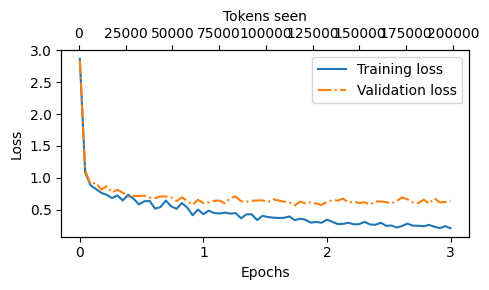

In [27]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [28]:
torch.manual_seed(123)


for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate_text_simple(
        model=gpt,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=GPT_CONFIG_345M["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
)

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")


Below is an instruction that describe a task. Wriite a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> ###Response:
The car is as fast as a cheetah.
-------------------------------------
Below is an instruction that describe a task. Wriite a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> ###Response:
A typical type of thunderstorm is a cumulus or cumulus cumulonimbus.
-------------------------------------
Below is an instruction that describe a task. Wriite a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> #

In [29]:
torch.save(gpt.state_dict(), "/content/drive/MyDrive/Colab Notebooks/gpt2_medium_finetuned.pt")
